<a href="https://colab.research.google.com/github/belhartrp/tugas-akhir-deep-learning/blob/main/tugasTerakhirDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tujuan: Membangun CNN sederhana untuk mengenali foto pribadi

Dataset: Foto kelas (kecuali foto diri sendiri)

In [1]:
# 1. IMPORT LIBRARY
# ============================================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')


In [2]:
print("=" * 80)
print("PRAKTIKUM 11: CNN PENGENALAN WAJAH")
print("=" * 80)

PRAKTIKUM 11: CNN PENGENALAN WAJAH


In [3]:
# 2. MOUNT GOOGLE DRIVE
# ============================================================================
print("\n[STEP 1] Mounting Google Drive...")
drive.mount('/content/drive')
print("✓ Google Drive berhasil dimount")


[STEP 1] Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive berhasil dimount


In [8]:
# 3. KONFIGURASI PATH
# ============================================================================
# UBAH PATH INI SESUAI LOKASI FOLDER DATASET ANDA DI GOOGLE DRIVE
DATASET_PATH = '/content/drive/MyDrive/Dataset_FotoCNN'  # UBAH SESUAI PATH ANDA
YOUR_NAME = 'Purba_Lamdippos_Hendry_Parmady'  # UBAH DENGAN NAMA ANDA LENGKAP (TANPA .jpg)

# Ukuran input
IMG_SIZE = 64
IMG_CHANNELS = 3

# Cek apakah folder ada
if not os.path.exists(DATASET_PATH):
    print(f"❌ ERROR: Folder {DATASET_PATH} tidak ditemukan!")
    print("Silakan ubah DATASET_PATH sesuai lokasi folder Anda di Google Drive")
else:
    print(f"✓ Dataset folder ditemukan: {DATASET_PATH}")

✓ Dataset folder ditemukan: /content/drive/MyDrive/Dataset_FotoCNN


In [9]:
# 4. PREPROCESSING FOTO
# ============================================================================
def load_and_preprocess_image(image_path):
    """
    Load foto dan preprocessing:
    - Resize ke 64x64
    - Normalisasi (dibagi 255)
    - Convert ke array
    """
    try:
        # Load gambar
        img = cv2.imread(image_path)

        if img is None:
            return None

        # Convert BGR to RGB (karena OpenCV membaca BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize ke 64x64
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalisasi (dibagi 255)
        img = img / 255.0

        return img
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        return None

print("\n[STEP 2] Preprocessing Foto...")

# List semua file foto
all_files = os.listdir(DATASET_PATH)
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Total foto ditemukan: {len(image_files)}")

# Separate training data (semua kecuali foto diri) dan testing data (foto diri)
training_images = []
training_labels = []
testing_image = None
testing_label = None

your_image_filename = f"{YOUR_NAME}.jpg"

for idx, filename in enumerate(image_files):
    filepath = os.path.join(DATASET_PATH, filename)
    img = load_and_preprocess_image(filepath)

    if img is not None:
        # Extract nama dari filename (hapus .jpg)
        person_name = os.path.splitext(filename)[0]

        # Cek apakah ini foto diri sendiri
        if filename.lower() == your_image_filename.lower():
            testing_image = img
            testing_label = person_name
            print(f"  ✓ Testing image ditemukan: {filename}")
        else:
            training_images.append(img)
            training_labels.append(person_name)

print(f"✓ Training images: {len(training_images)}")
print(f"✓ Testing images: 1 (Foto diri sendiri)")

# Validasi
if testing_image is None:
    print(f"❌ ERROR: Foto diri sendiri ({your_image_filename}) tidak ditemukan!")
    print(f"Pastikan nama file Anda di Google Drive sesuai format: {your_image_filename}")
else:
    print(f"✓ Data preprocessing selesai")

# Convert ke numpy array
X_train = np.array(training_images)
y_train = np.array(training_labels)

# Encode label (nama menjadi angka)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_train_categorical = to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))

num_classes = len(label_encoder.classes_)

print(f"\nDimensions:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train_categorical shape: {y_train_categorical.shape}")
print(f"  Jumlah kelas: {num_classes}")
print(f"  Nama-nama mahasiswa: {list(label_encoder.classes_)}")


[STEP 2] Preprocessing Foto...
Total foto ditemukan: 50
  ✓ Testing image ditemukan: Purba_Lamdippos_Hendry_Parmady.jpg
✓ Training images: 48
✓ Testing images: 1 (Foto diri sendiri)
✓ Data preprocessing selesai

Dimensions:
  X_train shape: (48, 64, 64, 3)
  y_train_categorical shape: (48, 48)
  Jumlah kelas: 48
  Nama-nama mahasiswa: [np.str_('Agung_Saruksuk'), np.str_('Alwi_Findo_Gultom'), np.str_('Andreas_Tarigan'), np.str_('Ari_Rivaldo_Simanjuntak'), np.str_('Aritmen_Andreas'), np.str_('Caleg_Sadrak_Sinaga'), np.str_('Congli_Silalahi'), np.str_('Daniel_Tariganz'), np.str_('Devi_Silvia_Simbolon'), np.str_('Diva_ferdinan_silalahi'), np.str_('Erick_Simanjuntak'), np.str_('Erikson_Tobing'), np.str_('FERA_SIHOTANG'), np.str_('Farel'), np.str_('Githa_Sabrina_Pasaribu'), np.str_('IMG'), np.str_('IMG-20260109-WA0051'), np.str_('IMG-20260109-WA0111'), np.str_('IMG-20260109-WA0130'), np.str_('Joy_Sofater_Purba'), np.str_('Juberto_Sinaga'), np.str_('Kevin_Enrique_Keliat'), np.str_('Kristian_

In [10]:
# 5. BUILD CNN MODEL
# ============================================================================
print("\n[STEP 3] Building CNN Model...")

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu",
                  input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Conv Block 2
    layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Conv Block 3
    layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten & Dense
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan model summary
print("\n" + "=" * 80)
print("MODEL SUMMARY")
print("=" * 80)
model.summary()


[STEP 3] Building CNN Model...

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         6,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,144 (4.38 MB)

 Trainable params: 1,148,144 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 6. TRAIN MODEL
# ============================================================================
print("\n[STEP 4] Training Model...")
print("=" * 80)

history = model.fit(
    X_train, y_train_categorical,
    epochs=50,  # Minimal 3 epoch
    batch_size=4,
    verbose=1,
    validation_split=0.2
)

print("\n✓ Training selesai!")


[STEP 4] Training Model...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 0.0000e+00 - loss: 3.9476 - val_accuracy: 0.0000e+00 - val_loss: 3.8949
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0263 - loss: 3.8719 - val_accuracy: 0.0000e+00 - val_loss: 3.9115
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0789 - loss: 3.8501 - val_accuracy: 0.0000e+00 - val_loss: 3.9823
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0526 - loss: 3.8224 - val_accuracy: 0.0000e+00 - val_loss: 4.2840
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0789 - loss: 3.7129 - val_accuracy: 0.0000e+00 - val_loss: 4.3857
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0263 - loss: 3.5797 - val_accuracy: 0.0000e+00 - val_loss: 4.7318
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1053 - loss: 3.4353 - val_accuracy: 0.0000e+00 - val_loss: 5.0001
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


[STEP 5] Visualisasi Training History...


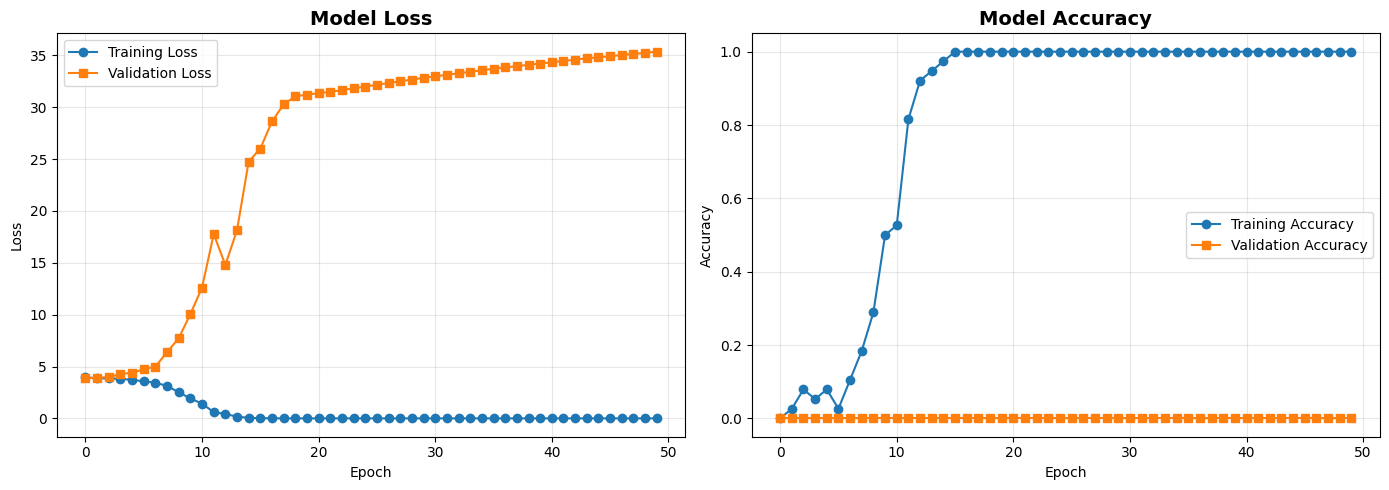

✓ Grafik disimpan: training_history.png


In [12]:
# 7. VISUALISASI TRAINING HISTORY
# ============================================================================
print("\n[STEP 5] Visualisasi Training History...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss graph
axes[0].plot(history.history['loss'], label='Training Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy graph
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik disimpan: training_history.png")

In [13]:
# 8. TEST DENGAN FOTO DIRI SENDIRI
# ============================================================================
print("\n[STEP 6] Testing dengan Foto Diri Sendiri...")
print("=" * 80)

# Reshape testing image
X_test = np.expand_dims(testing_image, axis=0)

# Predict
predictions = model.predict(X_test, verbose=0)
predicted_class_idx = np.argmax(predictions[0])
predicted_name = label_encoder.classes_[predicted_class_idx]
confidence = predictions[0][predicted_class_idx] * 100

print(f"\nHasil Prediksi:")
print(f"  Nama diprediksi: {predicted_name}")
print(f"  Confidence: {confidence:.2f}%")

# Top 3 predictions
top_3_idx = np.argsort(predictions[0])[-3:][::-1]
print(f"\nTop 3 Predictions:")
for i, idx in enumerate(top_3_idx, 1):
    print(f"  {i}. {label_encoder.classes_[idx]}: {predictions[0][idx]*100:.2f}%")


[STEP 6] Testing dengan Foto Diri Sendiri...

Hasil Prediksi:
  Nama diprediksi: Erikson_Tobing
  Confidence: 46.91%

Top 3 Predictions:
  1. Erikson_Tobing: 46.91%
  2. Aritmen_Andreas: 24.14%
  3. Steven_Ari_Paradongan_Silaban: 23.96%



[STEP 7] Visualisasi Hasil...


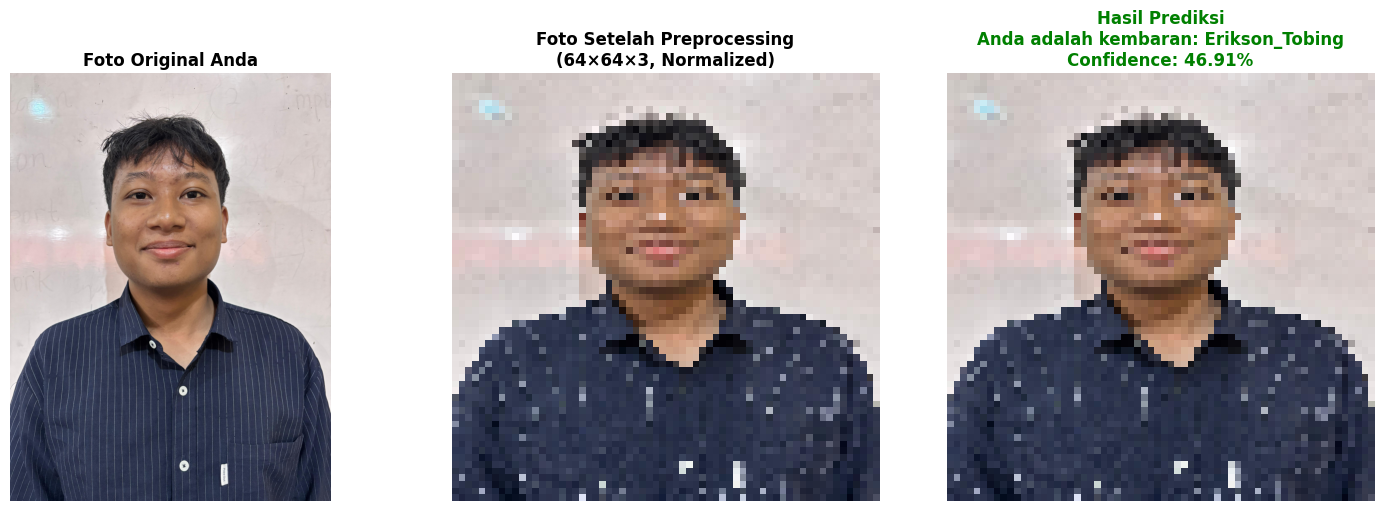

✓ Visualisasi hasil disimpan: result_prediction.png


In [14]:
# 9. VISUALISASI HASIL
# ============================================================================
print("\n[STEP 7] Visualisasi Hasil...")

# Load original image untuk ditampilkan
your_image_path = os.path.join(DATASET_PATH, your_image_filename)
original_img = cv2.imread(your_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(original_img)
axes[0].set_title('Foto Original Anda', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Preprocessed image
axes[1].imshow(testing_image)
axes[1].set_title(f'Foto Setelah Preprocessing\n(64×64×3, Normalized)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Prediction result
axes[2].imshow(testing_image)
axes[2].set_title(f'Hasil Prediksi\nAnda adalah kembaran: {predicted_name}\nConfidence: {confidence:.2f}%',
                 fontsize=12, fontweight='bold', color='green')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/result_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi hasil disimpan: result_prediction.png")


[STEP 7] Visualisasi Hasil...


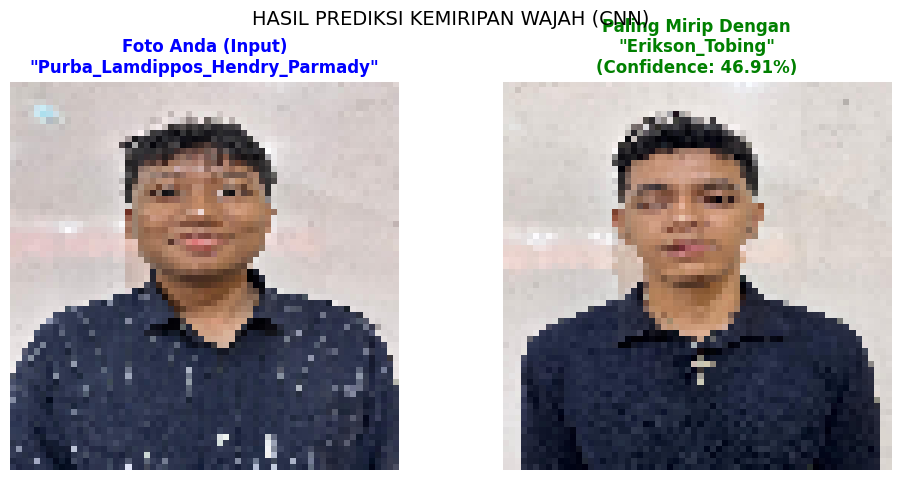

✓ Visualisasi hasil disimpan: result_prediction_comparison.png


In [15]:
# 9. VISUALISASI HASIL (FINAL - 2 GAMBAR SAJA)
# ============================================================================
print("\n[STEP 7] Visualisasi Hasil...")

# 1. Cari file foto kembaran berdasarkan nama prediksi
predicted_filename = None
for f in image_files:
    if os.path.splitext(f)[0] == predicted_name:
        predicted_filename = f
        break

# 2. Load foto kembaran dan preprocess
if predicted_filename:
    predicted_path = os.path.join(DATASET_PATH, predicted_filename)
    predicted_img_preprocessed = load_and_preprocess_image(predicted_path)
else:
    # Fallback jika file tidak ditemukan (seharusnya tidak terjadi)
    print("Warning: File kembaran tidak ditemukan, menampilkan blank image.")
    predicted_img_preprocessed = np.zeros((64, 64, 3))

# 3. PLOT 2 GAMBAR BERDAMPINGAN
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Gambar Kiri: ANDA ---
axes[0].imshow(testing_image)
axes[0].set_title(f'Foto Anda (Input)\n"{YOUR_NAME}"',
                 fontsize=12, fontweight='bold', color='blue')
axes[0].axis('off')

# --- Gambar Kanan: KEMBARAN ---
axes[1].imshow(predicted_img_preprocessed)
axes[1].set_title(f'Paling Mirip Dengan\n"{predicted_name}"\n(Confidence: {confidence:.2f}%)',
                 fontsize=12, fontweight='bold', color='green')
axes[1].axis('off')

# Judul Utama
plt.suptitle('HASIL PREDIKSI KEMIRIPAN WAJAH (CNN)', fontsize=14, y=0.95)

plt.tight_layout()
plt.savefig('/content/result_prediction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisasi hasil disimpan: result_prediction_comparison.png")


In [16]:
# 10. PENJELASAN ARSITEKTUR CNN
# ============================================================================
print("\n" + "=" * 80)
print("PENJELASAN ARSITEKTUR CNN")
print("=" * 80)

explanation = """
LAYER-LAYER CNN:

1. Conv2D(32, kernel=(3,3), padding='same', activation='relu')
   - Melakukan konvolusi dengan 32 filter ukuran 3×3
   - Padding 'same' mempertahankan dimensi spatial
   - ReLU activation: mengaktifkan nilai positif, menekan negatif
   - Fungsi: Mendeteksi fitur-fitur lokal (edge, texture) di level pertama

2. MaxPooling2D(2,2)
   - Mengurangi dimensi dengan mengambil nilai maksimal dari window 2×2
   - Fungsi: Mengurangi computational cost, menjaga fitur penting

3. Conv2D(64, kernel=(3,3), padding='same', activation='relu')
   - 64 filter untuk mendeteksi fitur lebih kompleks level kedua
   - Fungsi: Menggabungkan fitur lokal menjadi fitur-fitur yang lebih bermakna

4. MaxPooling2D(2,2)
   - Lanjutan downsampling

5. Conv2D(128, kernel=(3,3), padding='same', activation='relu')
   - 128 filter untuk mendeteksi fitur-fitur abstrak tingkat tinggi
   - Fungsi: Menangkap karakteristik wajah yang kompleks (bentuk wajah, pola unik)

6. MaxPooling2D(2,2)
   - Downsampling terakhir

7. Flatten()
   - Mengubah tensor 3D menjadi 1D vector
   - Fungsi: Mempersiapkan data untuk layer dense

8. Dense(128, activation='relu')
   - Fully connected layer dengan 128 neuron
   - ReLU activation untuk non-linearity
   - Fungsi: Belajar kombinasi kompleks dari fitur-fitur CNN

9. Dense(n_classes, activation='softmax')
   - Output layer dengan jumlah neuron = jumlah kelas (mahasiswa)
   - Softmax: mengkonversi output menjadi probabilitas
   - Fungsi: Memproduksi probabilitas untuk setiap mahasiswa

DIMENSI TENSOR SEPANJANG PIPELINE:
Input: (64, 64, 3)
├─ Conv2D(32) → (64, 64, 32)
├─ MaxPool → (32, 32, 32)
├─ Conv2D(64) → (32, 32, 64)
├─ MaxPool → (16, 16, 64)
├─ Conv2D(128) → (16, 16, 128)
├─ MaxPool → (8, 8, 128)
├─ Flatten → (8192,)
├─ Dense(128) → (128,)
└─ Dense(n_classes) → (n_classes,)

ALUR CARA KERJA:
1. Foto input (64×64×3) diproses melalui 3 blok convolutional
2. Setiap blok mengekstraksi fitur semakin abstrak
3. MaxPooling mengurangi dimensi namun menjaga fitur penting
4. Flatten mengubah map fitur 3D menjadi 1D vector
5. Dense layers belajar kombinasi fitur untuk prediksi
6. Output softmax memberikan probabilitas untuk setiap kelas
7. Kelas dengan probabilitas tertinggi adalah prediksi final
"""

print(explanation)


PENJELASAN ARSITEKTUR CNN

LAYER-LAYER CNN:

1. Conv2D(32, kernel=(3,3), padding='same', activation='relu')
   - Melakukan konvolusi dengan 32 filter ukuran 3×3
   - Padding 'same' mempertahankan dimensi spatial
   - ReLU activation: mengaktifkan nilai positif, menekan negatif
   - Fungsi: Mendeteksi fitur-fitur lokal (edge, texture) di level pertama

2. MaxPooling2D(2,2)
   - Mengurangi dimensi dengan mengambil nilai maksimal dari window 2×2
   - Fungsi: Mengurangi computational cost, menjaga fitur penting

3. Conv2D(64, kernel=(3,3), padding='same', activation='relu')
   - 64 filter untuk mendeteksi fitur lebih kompleks level kedua
   - Fungsi: Menggabungkan fitur lokal menjadi fitur-fitur yang lebih bermakna

4. MaxPooling2D(2,2)
   - Lanjutan downsampling

5. Conv2D(128, kernel=(3,3), padding='same', activation='relu')
   - 128 filter untuk mendeteksi fitur-fitur abstrak tingkat tinggi
   - Fungsi: Menangkap karakteristik wajah yang kompleks (bentuk wajah, pola unik)

6. MaxPoolin

In [ ]:
# 11. SIMPAN OUTPUT
# ============================================================================
print("\n[STEP 8] Menyimpan File Outputs...")

# Simpan model
model.save('/content/cnn_facematch_model.h5')
print("✓ Model disimpan: cnn_facematch_model.h5")

# Simpan predictions info
with open('/content/predictions_summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("CNN FACE MATCHING - HASIL PREDIKSI\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Foto Diri: {testing_label}\n")
    f.write(f"Kembaran Terdekat: {predicted_name}\n")
    f.write(f"Confidence: {confidence:.2f}%\n\n")
    f.write("Top 5 Predictions:\n")
    top_5_idx = np.argsort(predictions[0])[-5:][::-1]
    for i, idx in enumerate(top_5_idx, 1):
        f.write(f"  {i}. {label_encoder.classes_[idx]}: {predictions[0][idx]*100:.2f}%\n")

print("✓ Summary disimpan: predictions_summary.txt")

print("\n" + "=" * 80)
print("✓ PRAKTIKUM 11 SELESAI!")
print("=" * 80)
print("\nFile outputs:")
print("  - training_history.png")
print("  - result_prediction.png")
print("  - cnn_faceatch_model.h5")
print("  - predictions_summary.txt")
print("\nGunakan file-file tersebut untuk membuat laporan PDF Anda!")